# Tracé des futurs changements des POE des ETCs de la région Sud Québec dans le futur
Les métriques sont calculées avec la méthode de la différence entre la variable et son centile, de sorte à pouvoir calculer leur changement relatif d'un point de vue physique (changement en unité, et pas changement en changement relatif), contrairement au programme similaire sans _diff.

In [1]:
import pandas as pd
from glob import glob
from braceexpand import braceexpand
import numpy as np
import matplotlib.pyplot as plt
import pickle
import xarray as xr
from scipy.stats import gaussian_kde
from matplotlib.ticker import ScalarFormatter
import sys
import os
from matplotlib.lines import Line2D
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'POSTPROCESSING')))
from ETC_tools import calculate_ranking, open_files
from matplotlib.ticker import AutoMinorLocator
import matplotlib.ticker as ticker

## Introduction

### Déclaration des variables

In [2]:
simulations = ['UBD', 'UBE', 'UBF', 'UBG', 'UBH', 'UBI']
sim_hist_fut = {'UBD': 'UBG', 'UBE': 'UBH', 'UBF': 'UBI'}

quantile = 0.99
metric = 'diff' #How the metrics have been calculated (diff or ratio)
if metric == 'ratio':
    thr_value = 1.
elif metric == 'diff':
    thr_value = 0.

### Ouverture des fichiers

In [3]:
EETC_dict = {}
df = {}

for sim in simulations:        
    df_sim, EETC_dict_sim = open_files(sim, metric=metric, wetdays=False, future=True, original_selection=False, period_filtering=True) #wetdays=True, future=False car on compare les métriques hist vs fut sans pouvoir comparer les centiles pour le moment
    
    EETC_dict[sim] = EETC_dict_sim
    df[sim] = df_sim

Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/EETC/EETC_cum_UBD_Quebec_1005hPa_1979-2014_compound_8hrs_quantile_SSI_diff.pkl with True period filtering
Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/EETC/EETC_cum_UBE_Quebec_1005hPa_1979-2014_compound_8hrs_quantile_SSI_diff.pkl with True period filtering
Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/EETC/EETC_cum_UBF_Quebec_1005hPa_1979-2014_compound_8hrs_quantile_SSI_diff.pkl with True period filtering
Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/EETC/EETC_cum_UBG_Quebec_1005hPa_1979-2100_compound_8hrs_quantile_SSI_future_percentile_diff.pkl with True period filtering
Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/EETC/EETC_cum_UBH_Quebec_1005hPa_1979-2100_compound_8hrs_quantile_SSI_future_percentile_diff.pkl with True period filtering
Load

### We associate the date at which the pressure was minimum for each extreme ETCs of the dict, to later do a seasonal discrimation

In [11]:
metrics = ['cum_precip', 'cum_avg_precip', 'cum_wind', 'cum_avg_wind']
for sim in simulations:
    for storm in EETC_dict[sim]:
        if (
            any(EETC_dict[sim][storm][m].sel(quantile=quantile).values > thr_value for m in metrics)
            or (EETC_dict[sim][storm]['SSI'].sel(quantile=quantile).values != 0)
        ):
            storm_group = df[sim].groupby('storm').get_group(storm)
            min_pressure_row = storm_group.loc[storm_group['pressure'].idxmin()]
            EETC_dict[sim][storm]['min_pressure_date'] = min_pressure_row['date']

### Paramètres utile pour les plots

In [4]:
plot_params = [
    {
        "var": "cum_precip",
        "label": '$ETC_{PR,cum}|_{QC}$',
        "unit": '[mm]',
        "ax_index": (0, 0)
    },
    {
        "var": "cum_avg_precip",
        "label": '$\overline{{ETC}_{PR}|_{QC}}$',
        "unit": '[mm.h$^{{-1}}$]',
        "ax_index": (0, 1)
    },
    # {
    #     "var": "SSI",
    #     "label": '$SSI$',
    #     "ax_index": (1, 0)
    # },
    {
        "var": "cum_wind",
        "label": '$ETC_{WS,cum}|_{QC}$',
        "unit": '[km.h$^{{-1}}$]', 
        "ax_index": (1, 0)
    },
    {
        "var": "cum_avg_wind",
        "label": '$\overline{{ETC}_{WS}|_{QC}}$',
        "unit": '[km.h$^{{-1}}$]', 
        "ax_index": (1, 1)
    }
]

sim_linestyles = {
    'UBD': '-',
    'UBE': ':',
    'UBF': '--',
    'UBG': '-',
    'UBH': ':',
    'UBI': '--',
}

sim_label = {
    'ERA5': r'ERA5',
    'UBB': r'CRCM6$_{\mathrm{ERA5}}$',
    'UBD': r'CRCM6$_{\mathrm{EC\text{-}Earth3\text{-}Veg}}$',
    'UBG': r'CRCM6$_{\mathrm{EC\text{-}Earth3\text{-}Veg}}$',
    'UBE': r'CRCM6$_{\mathrm{MPI\text{-}ESM1\text{-}2\text{-}HR}}$',
    'UBH': r'CRCM6$_{\mathrm{MPI\text{-}ESM1\text{-}2\text{-}HR}}$',
    'UBF': r'CRCM6$_{\mathrm{MIROC6}}$',
    'UBI': r'CRCM6$_{\mathrm{MIROC6}}$' 
}

sim_color = {
    'UBD': '#1f77b4',
    'UBE': '#ff7f0e',
    'UBF': '#2ca02c',
    'UBG': '#1f77b4',
    'UBH': '#ff7f0e',
    'UBI': '#2ca02c',
}

seasons = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}

season_color = {'DJF': '#7eb7de', 'MAM': '#2ca02c', 'JJA': '#ff7f0e', 'SON': '#d62728'}

def clean_log_format(x, pos):
    if x >= 1 and x == int(x):
        return str(int(x))  # Affiche 1, 10, 100
    elif x < 1:
        return f"{x:.1g}"   # Par exemple : 0.1
    else:
        return str(x)

## Tracé des plots

### Distribution des EETCs au Québec Sud sous forme de PoE

#### PoE historique vs future échelle log

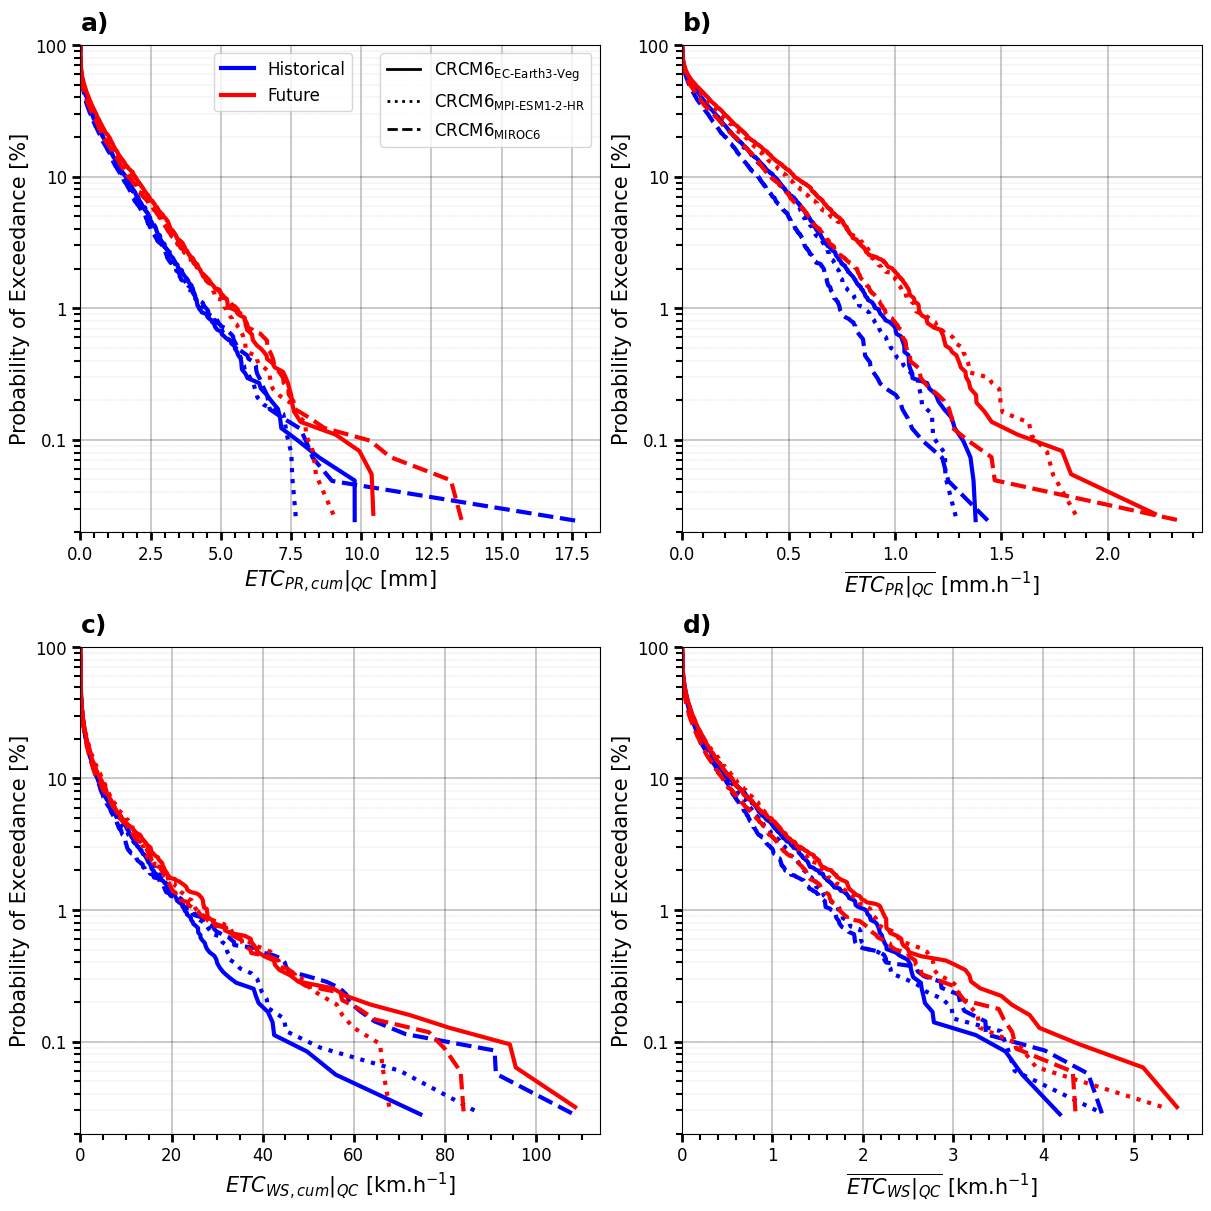

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for i, params in enumerate(plot_params):
    ax = axes[params["ax_index"]]
    
    for isim, sim in enumerate(simulations):
   
        EETCs_var = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
        ]
            
        # Sort values for probability of exceedance
        sorted_vals = np.sort(EETCs_var)[::-1]  # Sort in descending order
        prob_exceedance = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)  # Calculate exceedance probability

        if sim in sim_hist_fut:
            color = 'blue'
        else:
            color = 'red'
        
        ax.plot(sorted_vals, prob_exceedance * 100, color=color, linestyle=sim_linestyles[sim], linewidth=3)
        
    letter = f"$\\mathbf{{{chr(97+i)})}}$"
    ax.text(0, 1.02, letter, transform=ax.transAxes, fontsize=18, ha='left', va='bottom')
    ax.set_xlim(0, None)
    # ax.set_ylim(-1.3, 2)  # Set y-axis limits to stop at 10^0
    ax.set_ylim(0.02, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"] + ' ' + params["unit"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # if params["ax_index"] == (0, 0): ax.legend(fontsize=12, loc='upper right')
    if params["ax_index"] == (0, 0):
        model_handles = [
            Line2D([0], [0], color='k', linewidth=2, linestyle=sim_linestyles['UBD'], label=r'CRCM6$_{\mathrm{EC\text{-}Earth3\text{-}Veg}}$'),
            Line2D([0], [0], color='k', linewidth=2, linestyle=sim_linestyles['UBE'], label=r'CRCM6$_{\mathrm{MPI\text{-}ESM1\text{-}2\text{-}HR}}$'),
            Line2D([0], [0], color='k', linewidth=2, linestyle=sim_linestyles['UBF'], label=r'CRCM6$_{\mathrm{MIROC6}}$')
        ]
        period_handles = [
            Line2D([0], [0], color='blue', linewidth=3, label='Historical'),
            Line2D([0], [0], color='red',  linewidth=3, label='Future')
        ]
        legend1 = ax.legend(handles=model_handles, loc='upper right', fontsize=12)
        ax.add_artist(legend1)
        ax.legend(handles=period_handles, loc='upper center', bbox_to_anchor=(0.39, 1), fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

# fig.suptitle(f"Probability of Exceedance of the strongest ETCs over Québec — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

#### Changement dans le futur du seuil des métriques en fonction de la PoE

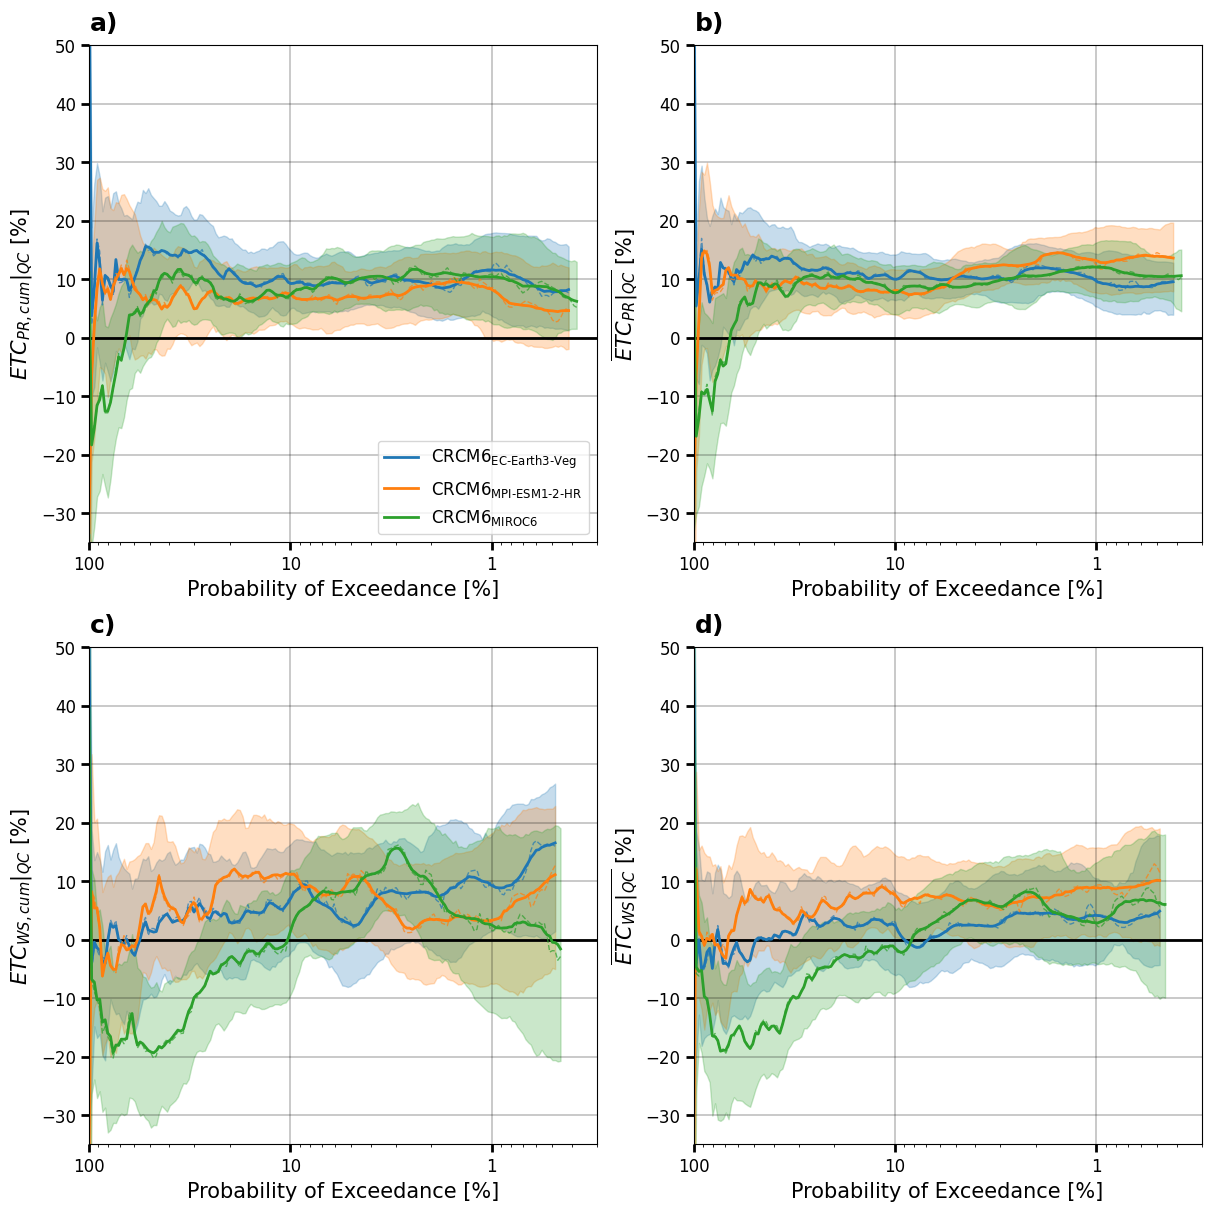

In [22]:
common_poe = np.logspace(np.log10(0.01), np.log10(100), 300)
min_events_threshold = 15

# --- paramètres bootstrap ---
nboot = 1000  # augmente si tu veux des CI plus lisses
ci_lower = 2.5
ci_upper = 97.5

fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for i, params in enumerate(plot_params):
    
    ax = axes[params["ax_index"]]
    ax.axhline(y=0, color='k', lw=2)
    
    for isim, sim in enumerate(sim_hist_fut):
        
        # --- récupère les valeurs par cyclone ---
        EETCs_hist = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
        ]
        
        EETCs_fut = [
            EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim_hist_fut[sim]]
            if EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
        ]
        
        n_hist = len(EETCs_hist)
        n_fut  = len(EETCs_fut)
        
        # Trie les valeurs (descendant)
        EETCs_hist_sorted = np.sort(np.asarray(EETCs_hist))[::-1]
        EETCs_fut_sorted = np.sort(np.asarray(EETCs_fut))[::-1]

        # poe observés
        poe_hist = 100 * (np.arange(1, n_hist + 1) / n_hist)
        poe_fut  = 100 * (np.arange(1, n_fut + 1) / n_fut)           
            
        # interp sur grille commune
        interp_hist = np.interp(common_poe, poe_hist, EETCs_hist_sorted, left=np.nan, right=np.nan)
        interp_fut  = np.interp(common_poe, poe_fut,  EETCs_fut_sorted,  left=np.nan, right=np.nan)

        # diff observée (ta formule, en % relatif)
        diff_obs = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)
        
        # --- Masque de validité (Règle des 15 cyclones) ---
        # On veut que le niveau de probabilité (PoE) représente au moins 15 événements 
        # DANS LES DEUX distributions pour que la comparaison soit solide.
        # Quelle est la PoE minimale fiable pour l'historique ? (ex: 15/1000 = 1.5%)
        min_poe_hist = (min_events_threshold / n_hist) * 100
        # Quelle est la PoE minimale fiable pour le futur ? (ex: 15/1500 = 1.0%)
        min_poe_fut  = (min_events_threshold / n_fut) * 100
        # On doit être au-dessus du PIRE des deux seuils (le plus restrictif)
        cutoff_poe = max(min_poe_hist, min_poe_fut)
        mask_valid = common_poe >= cutoff_poe
        # On applique le masque pour le plot
        diff_obs[~mask_valid] = np.nan
        
        # ----------------------
        # BOOTSTRAP (pointwise)
        # ----------------------
        boot_changes = np.full((nboot, common_poe.size), np.nan)

        for ib in range(nboot):
            # resample indices avec remise (cyclones entiers)
            idx_hist = np.random.randint(0, n_hist, size=n_hist)
            idx_fut  = np.random.randint(0, n_fut,  size=n_fut)

            h_b = np.sort(np.asarray(EETCs_hist_sorted)[idx_hist])[::-1]
            f_b = np.sort(np.asarray(EETCs_fut_sorted)[idx_fut])[::-1]

            poe_h_b = 100 * (np.arange(1, len(h_b) + 1) / len(h_b))
            poe_f_b = 100 * (np.arange(1, len(f_b) + 1) / len(f_b))

            interp_h_b = np.interp(common_poe, poe_h_b, h_b, left=np.nan, right=np.nan)
            interp_f_b = np.interp(common_poe, poe_f_b, f_b, left=np.nan, right=np.nan)

            # calcule diff bootstrap (même formule)
            diff_b = 100 * (interp_f_b - interp_h_b) / (interp_f_b + interp_h_b)

            boot_changes[ib, :] = diff_b

        # percentiles pointwise en tolérant NaN (zones trop rares resteront NaN)
        lower = np.nanpercentile(boot_changes, ci_lower, axis=0)
        median = np.nanpercentile(boot_changes, 50, axis=0)
        upper = np.nanpercentile(boot_changes, ci_upper, axis=0)
        
        # On applique le masque de validité (règle des 15 cyclones) aux résultats du bootstrap
        lower[~mask_valid] = np.nan
        median[~mask_valid] = np.nan
        upper[~mask_valid] = np.nan
        
        # plot: bande CI (masque les NaN) puis médiane et courbe observée
        valid = (~np.isnan(lower)) & (~np.isnan(upper))
        label = sim_label[sim]

        if np.any(valid):
            ax.fill_between(common_poe[valid], lower[valid], upper[valid], alpha=0.25, color=sim_color[sim])
            ax.plot(common_poe, median, linewidth=2, color=sim_color[sim], label=label)
        # plot de ta courbe observée (optionnel: en trait noir pointillé)
        ax.plot(common_poe, diff_obs, lw=1, color=sim_color[sim], linestyle='--', alpha=0.7)
        
    letter = f"$\\mathbf{{{chr(97+i)})}}$"
    ax.text(0, 1.02, letter, transform=ax.transAxes, fontsize=18, ha='left', va='bottom')
    ax.set_xlabel("Probability of Exceedance [%]", fontsize=15)
    ax.set_xlim(100, 0.3)
    ax.set_xscale('log')
    ax.set_ylabel(params["label"] + ' [%]', fontsize=15)
    ax.set_ylim(-35, 50)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    if params["ax_index"] == (0, 0): ax.legend(fontsize=12, loc='lower right')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')

#### Changement dans le futur de la probabilité d'excéder un seuil de métrique

NameError: name 'change_label' is not defined

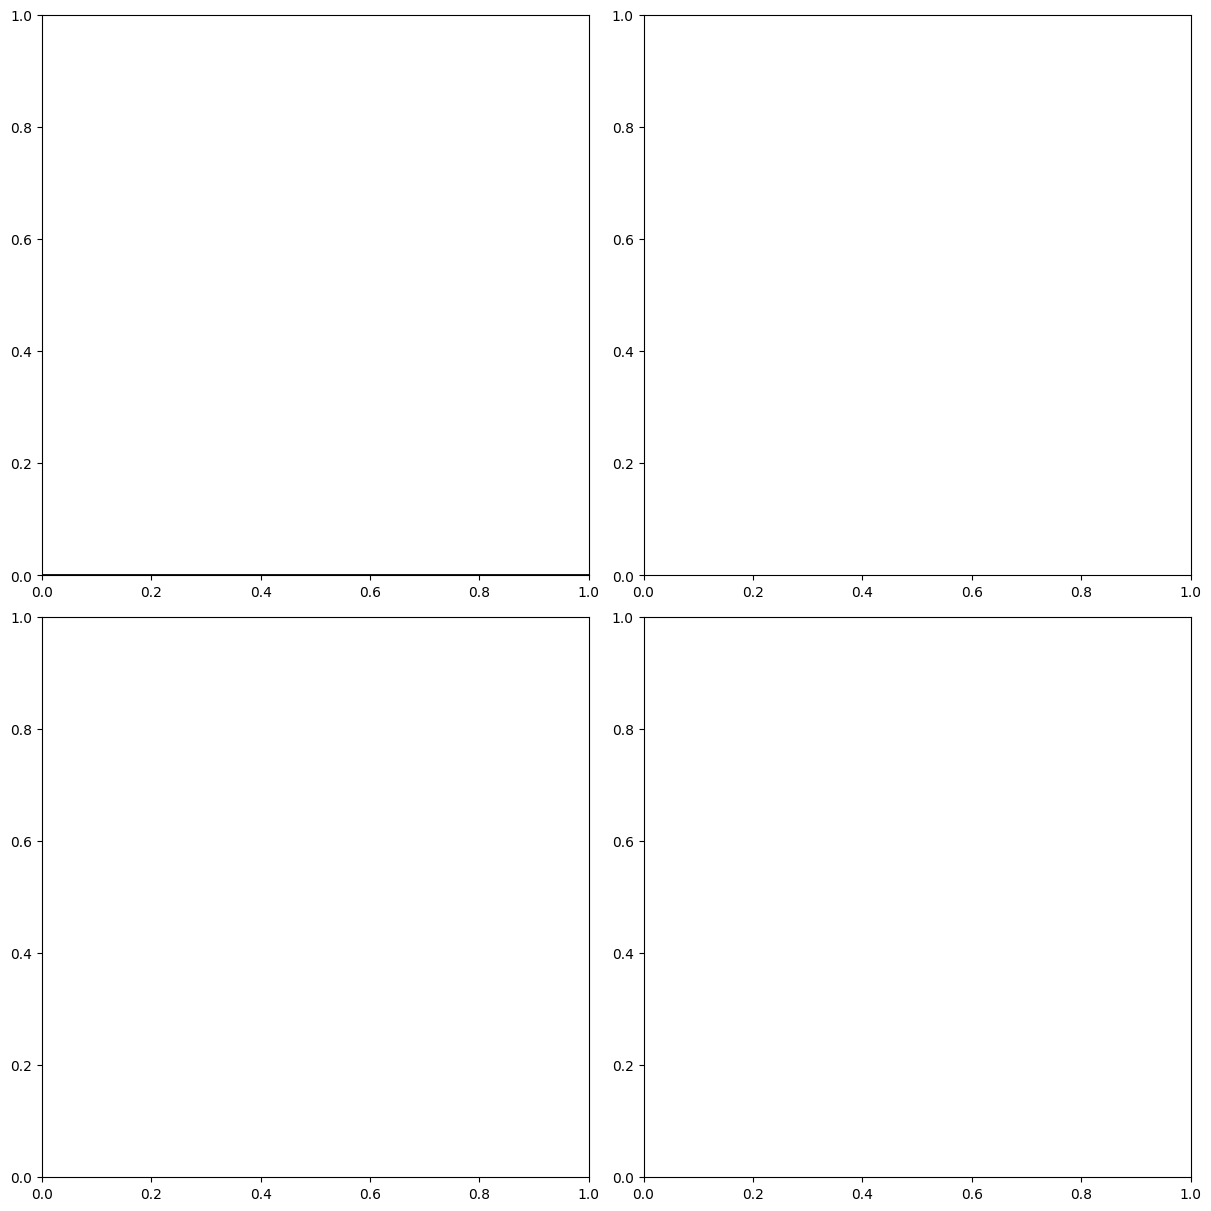

In [13]:
# --- paramètres bootstrap ---
nboot = 1000  # augmente si tu veux des CI plus lisses
ci_lower = 2.5
ci_upper = 97.5

fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for params in plot_params:
    
    ax = axes[params["ax_index"]]
    ax.axhline(y=0, color='k', lw=2)
    
    for isim, sim in enumerate(sim_hist_fut):
        
        EETCs_hist = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
        ]
        
        EETCs_fut = [
            EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim_hist_fut[sim]]
            if EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
        ]
        
        # Trie les valeurs
        EETCs_hist_sorted = np.sort(np.asarray(EETCs_hist))#[::-1]
        EETCs_fut_sorted = np.sort(np.asarray(EETCs_fut))#[::-1]
        
        common_metric_value = np.linspace(thr_value, max(EETCs_hist_sorted.max(), EETCs_fut_sorted.max()), 500)
        
        # Calcule les poe correspondants
        poe_hist = 100 * (np.arange(1, len(EETCs_hist_sorted) + 1) / len(EETCs_hist_sorted))
        poe_fut = 100 * (np.arange(1, len(EETCs_fut_sorted) + 1) / len(EETCs_fut_sorted))
        
        poe_hist = poe_hist[::-1] #interp nécessite une grille croissante (EETCs_hist_sorted et common_metric_value), donc j'inverse l'ordre de tout, dont les POE
        poe_fut = poe_fut[::-1]

        # Interpole sur la grille commune
        interp_hist = np.interp(common_metric_value, EETCs_hist_sorted, poe_hist, right=np.nan)
        interp_fut = np.interp(common_metric_value, EETCs_fut_sorted, poe_fut, right=np.nan)

        # Calcule la différence (futur - historique)
        diff_obs = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)

        # ----------------------
        # BOOTSTRAP (pointwise)
        # ----------------------
        boot_changes = np.full((nboot, common_metric_value.size), np.nan)

        n_hist = len(EETCs_hist_sorted)
        n_fut  = len(EETCs_fut_sorted)

        for ib in range(nboot):
            # resample indices avec remise (cyclones entiers)
            idx_hist = np.random.randint(0, n_hist, size=n_hist)
            idx_fut  = np.random.randint(0, n_fut,  size=n_fut)

            h_b = np.sort(np.asarray(EETCs_hist_sorted)[idx_hist])#[::-1]
            f_b = np.sort(np.asarray(EETCs_fut_sorted)[idx_fut])#[::-1]

            poe_h_b = 100 * (np.arange(1, len(h_b) + 1) / len(h_b))
            poe_f_b = 100 * (np.arange(1, len(f_b) + 1) / len(f_b))

            poe_h_b = poe_h_b[::-1]
            poe_f_b = poe_f_b[::-1]

            interp_h_b = np.interp(common_metric_value, h_b, poe_h_b, right=np.nan)
            interp_f_b = np.interp(common_metric_value, f_b, poe_f_b, right=np.nan)

            # calcule diff bootstrap (même formule)
            diff_b = 100 * (interp_f_b - interp_h_b) / (interp_f_b + interp_h_b)

            boot_changes[ib, :] = diff_b

        # percentiles pointwise en tolérant NaN (zones trop rares resteront NaN)
        lower = np.nanpercentile(boot_changes, ci_lower, axis=0)
        median = np.nanpercentile(boot_changes, 50, axis=0)
        upper = np.nanpercentile(boot_changes, ci_upper, axis=0)

        # plot: bande CI (masque les NaN) puis médiane et courbe observée
        valid = (~np.isnan(lower)) & (~np.isnan(upper))
        label = sim_label[sim]

        if np.any(valid):
            ax.fill_between(common_metric_value[valid], lower[valid], upper[valid], alpha=0.25, color=sim_color[sim])
            ax.plot(common_metric_value, median, linewidth=2, color=sim_color[sim], label=label + ' (median)')
        # plot de ta courbe observée (optionnel: en trait noir pointillé)
        ax.plot(common_metric_value, diff_obs, lw=1, color=sim_color[sim], linestyle='--', alpha=0.7)
        
    ax.set_xlabel(params["label"] + ' ' + params["unit"], fontsize=15)
    ax.set_xlim(0, None)
    # ax.set_xscale('log')
    ax.set_ylabel("PoE relative change [%]", fontsize=15)
    # ax.set_ylim(-0, 0.3)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    if params["ax_index"] == (0, 0): ax.legend(fontsize=12, loc='best')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')

# plt.savefig('/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/POE_diff_UBD_fut_vs_hist_season.png', dpi=70, bbox_inches='tight', transparent=True)

### Plots saisonniers

#### EC-Earth3-Veg

##### Changement dans le futur du seuil des métriques en fonction de la PoE

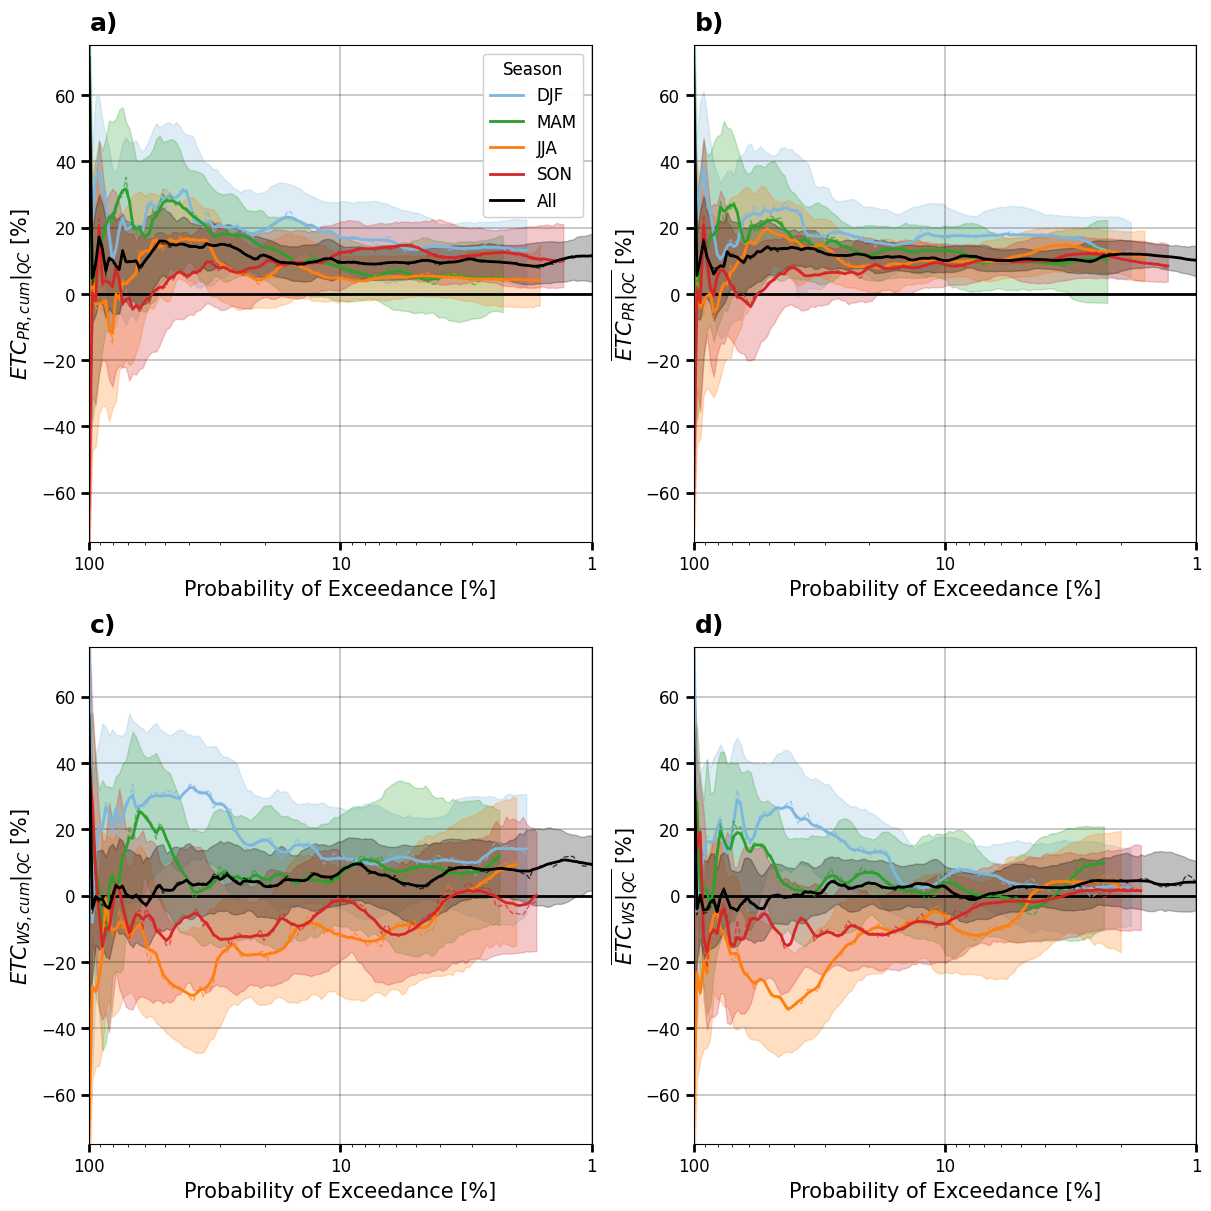

In [25]:
sim = 'UBD'

common_poe = np.logspace(np.log10(0.01), np.log10(100), 300)
min_events_threshold = 15

# --- paramètres bootstrap ---
nboot = 1000  # augmente si tu veux des CI plus lisses
ci_lower = 2.5
ci_upper = 97.5

fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for i, params in enumerate(plot_params):
    
    ax = axes[params["ax_index"]]
    ax.axhline(y=0, color='k', lw=2)
    
    for season, months in seasons.items():

        EETCs_hist = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if (
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            )
        ]
        EETCs_fut = [
            EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim_hist_fut[sim]]
            if (
                EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim_hist_fut[sim]][k]['min_pressure_date']).month in months
            )
        ]
        
        n_hist = len(EETCs_hist)
        n_fut  = len(EETCs_fut)
        
        # Trie les valeurs (descendant)
        EETCs_hist_sorted = np.sort(np.asarray(EETCs_hist))[::-1]
        EETCs_fut_sorted = np.sort(np.asarray(EETCs_fut))[::-1]

        # poe observés
        poe_hist = 100 * (np.arange(1, n_hist + 1) / n_hist)
        poe_fut  = 100 * (np.arange(1, n_fut + 1) / n_fut)

        # interp sur grille commune
        interp_hist = np.interp(common_poe, poe_hist, EETCs_hist_sorted, left=np.nan, right=np.nan)
        interp_fut  = np.interp(common_poe, poe_fut,  EETCs_fut_sorted,  left=np.nan, right=np.nan)

        # diff observée (ta formule, en % relatif)
        diff_obs = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)
        
        # --- Masque de validité (Règle des 15 cyclones) ---
        min_poe_hist = (min_events_threshold / n_hist) * 100
        min_poe_fut  = (min_events_threshold / n_fut) * 100
        cutoff_poe = max(min_poe_hist, min_poe_fut)
        mask_valid = common_poe >= cutoff_poe
        diff_obs[~mask_valid] = np.nan
        
        # ----------------------
        # BOOTSTRAP (pointwise)
        # ----------------------
        boot_changes = np.full((nboot, common_poe.size), np.nan)

        n_hist = len(EETCs_hist_sorted)
        n_fut  = len(EETCs_fut_sorted)

        for ib in range(nboot):
            # resample indices avec remise (cyclones entiers)
            idx_hist = np.random.randint(0, n_hist, size=n_hist)
            idx_fut  = np.random.randint(0, n_fut,  size=n_fut)

            h_b = np.sort(np.asarray(EETCs_hist_sorted)[idx_hist])[::-1]
            f_b = np.sort(np.asarray(EETCs_fut_sorted)[idx_fut])[::-1]

            poe_h_b = 100 * (np.arange(1, len(h_b) + 1) / len(h_b))
            poe_f_b = 100 * (np.arange(1, len(f_b) + 1) / len(f_b))

            interp_h_b = np.interp(common_poe, poe_h_b, h_b, left=np.nan, right=np.nan)
            interp_f_b = np.interp(common_poe, poe_f_b, f_b, left=np.nan, right=np.nan)

            # calcule diff bootstrap (même formule)
            diff_b = 100 * (interp_f_b - interp_h_b) / (interp_f_b + interp_h_b)

            boot_changes[ib, :] = diff_b

        # percentiles pointwise en tolérant NaN (zones trop rares resteront NaN)
        lower = np.nanpercentile(boot_changes, ci_lower, axis=0)
        median = np.nanpercentile(boot_changes, 50, axis=0)
        upper = np.nanpercentile(boot_changes, ci_upper, axis=0)
        
        # On applique le masque de validité (règle des 15 cyclones) aux résultats du bootstrap
        lower[~mask_valid] = np.nan
        median[~mask_valid] = np.nan
        upper[~mask_valid] = np.nan
        
        # plot: bande CI (masque les NaN) puis médiane et courbe observée
        valid = (~np.isnan(lower)) & (~np.isnan(upper))
        label = sim_label[sim]

        if np.any(valid):
            ax.fill_between(common_poe[valid], lower[valid], upper[valid], alpha=0.25, color=season_color[season])
            ax.plot(common_poe, median, linewidth=2, color=season_color[season])
        # plot de ta courbe observée (optionnel: en trait noir pointillé)
        ax.plot(common_poe, diff_obs, lw=1, color=season_color[season], linestyle='--', alpha=0.7)

    EETCs_hist = [
        EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim]
        if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]
    
    EETCs_fut = [
        EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim_hist_fut[sim]]
        if EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]
    
    n_hist = len(EETCs_hist)
    n_fut  = len(EETCs_fut)
    
    # Trie les valeurs (descendant)
    EETCs_hist_sorted = np.sort(np.asarray(EETCs_hist))[::-1]
    EETCs_fut_sorted = np.sort(np.asarray(EETCs_fut))[::-1]

    # poe observés
    poe_hist = 100 * (np.arange(1, n_hist + 1) / n_hist)
    poe_fut  = 100 * (np.arange(1, n_fut + 1) / n_fut)  

    # interp sur grille commune
    interp_hist = np.interp(common_poe, poe_hist, EETCs_hist_sorted, left=np.nan, right=np.nan)
    interp_fut  = np.interp(common_poe, poe_fut,  EETCs_fut_sorted,  left=np.nan, right=np.nan)

    # diff observée (ta formule, en % relatif)
    diff_obs = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)
    
    # --- Masque de validité (Règle des 15 cyclones) ---
    min_poe_hist = (min_events_threshold / n_hist) * 100
    min_poe_fut  = (min_events_threshold / n_fut) * 100
    cutoff_poe = max(min_poe_hist, min_poe_fut)
    mask_valid = common_poe >= cutoff_poe
    diff_obs[~mask_valid] = np.nan

    # ----------------------
    # BOOTSTRAP (pointwise)
    # ----------------------
    boot_changes = np.full((nboot, common_poe.size), np.nan)

    n_hist = len(EETCs_hist_sorted)
    n_fut  = len(EETCs_fut_sorted)

    for ib in range(nboot):
        # resample indices avec remise (cyclones entiers)
        idx_hist = np.random.randint(0, n_hist, size=n_hist)
        idx_fut  = np.random.randint(0, n_fut,  size=n_fut)

        h_b = np.sort(np.asarray(EETCs_hist_sorted)[idx_hist])[::-1]
        f_b = np.sort(np.asarray(EETCs_fut_sorted)[idx_fut])[::-1]

        poe_h_b = 100 * (np.arange(1, len(h_b) + 1) / len(h_b))
        poe_f_b = 100 * (np.arange(1, len(f_b) + 1) / len(f_b))

        interp_h_b = np.interp(common_poe, poe_h_b, h_b, left=np.nan, right=np.nan)
        interp_f_b = np.interp(common_poe, poe_f_b, f_b, left=np.nan, right=np.nan)

        # calcule diff bootstrap (même formule)
        diff_b = 100 * (interp_f_b - interp_h_b) / (interp_f_b + interp_h_b)

        boot_changes[ib, :] = diff_b

    # percentiles pointwise en tolérant NaN (zones trop rares resteront NaN)
    lower = np.nanpercentile(boot_changes, ci_lower, axis=0)
    median = np.nanpercentile(boot_changes, 50, axis=0)
    upper = np.nanpercentile(boot_changes, ci_upper, axis=0)
    
    # On applique le masque de validité (règle des 15 cyclones) aux résultats du bootstrap
    lower[~mask_valid] = np.nan
    median[~mask_valid] = np.nan
    upper[~mask_valid] = np.nan

    # plot: bande CI (masque les NaN) puis médiane et courbe observée
    valid = (~np.isnan(lower)) & (~np.isnan(upper))
    label = sim_label[sim]

    if np.any(valid):
        ax.fill_between(common_poe[valid], lower[valid], upper[valid], alpha=0.25, color='k')
        ax.plot(common_poe, median, linewidth=2, color='k')
    # plot de ta courbe observée (optionnel: en trait noir pointillé)
    ax.plot(common_poe, diff_obs, lw=1, color='k', linestyle='--', alpha=0.7)
    
    letter = f"$\\mathbf{{{chr(97+i)})}}$"
    ax.text(0, 1.02, letter, transform=ax.transAxes, fontsize=18, ha='left', va='bottom')
    ax.set_xlabel("Probability of Exceedance [%]", fontsize=15)
    ax.set_xlim(100, 1)
    ax.set_xscale('log')
    ax.set_ylabel(params["label"] + ' [%]', fontsize=15)
    ax.set_ylim(-75, 75)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    if params["ax_index"] == (0, 0):
        season_handles = [
            Line2D([0], [0], color=season_color[season], linestyle='-', linewidth=2, label=season)
            for season in seasons]
    
        season_handles.append(
        Line2D([0], [0], color='k', linestyle='-', linewidth=2, label='All'))
        
        legend1 = ax.legend(handles=season_handles, title='Season', loc='best', fontsize=12, title_fontsize=12)
    
        ax.add_artist(legend1)
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')

#### MPI-ESM1-2-HR

##### Changement dans le futur du seuil des métriques en fonction de la PoE

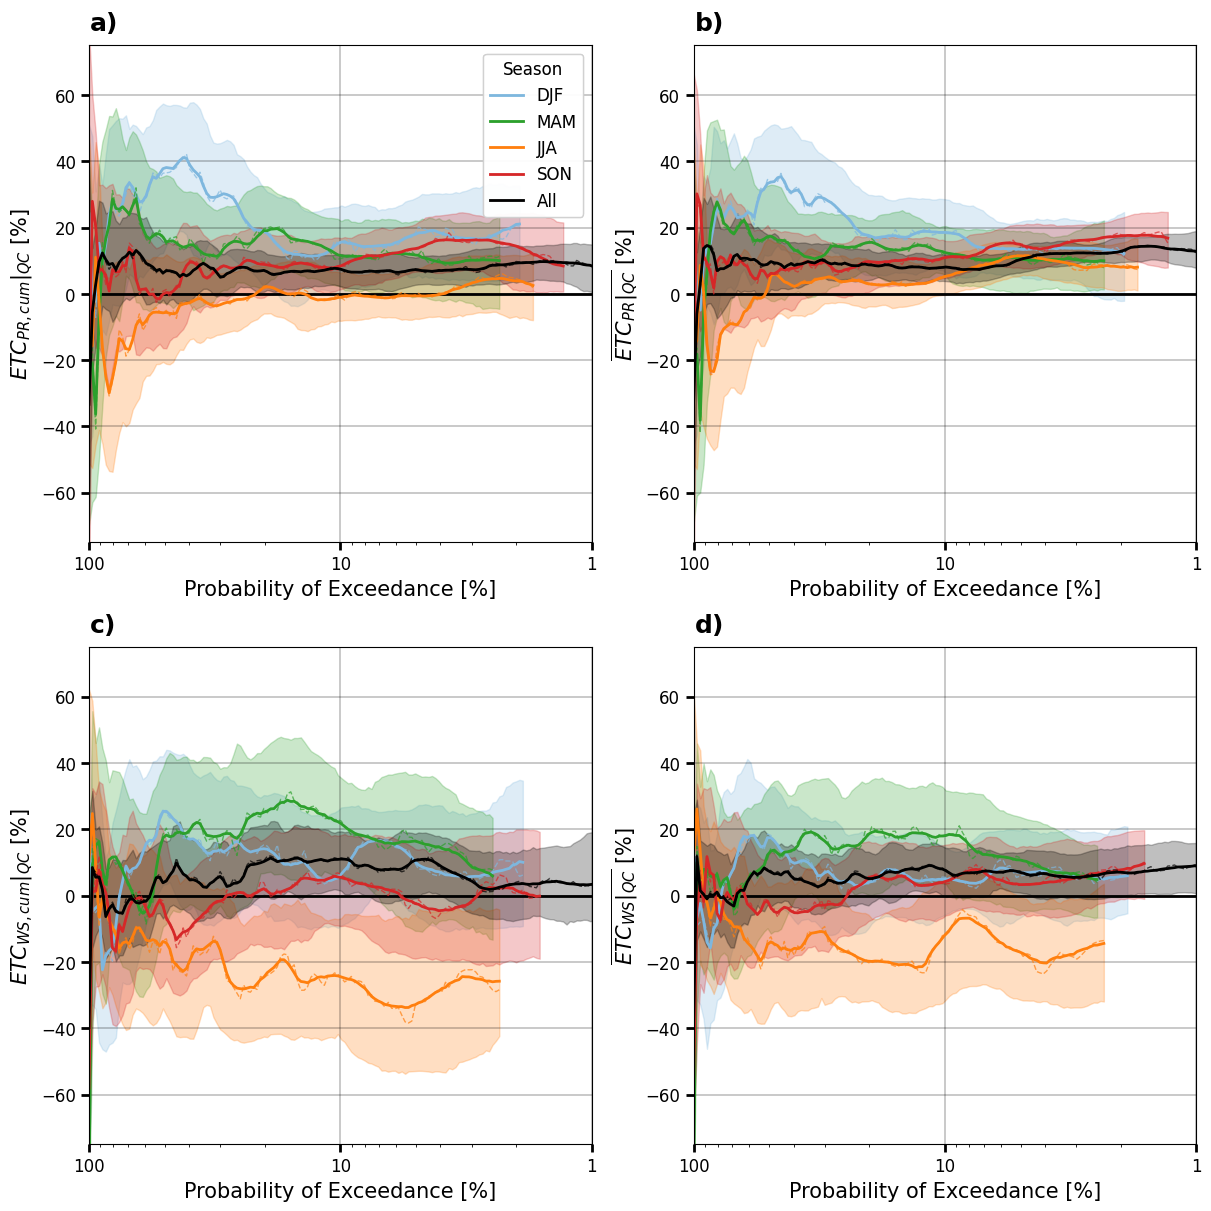

In [24]:
sim = 'UBE'
common_poe = np.logspace(np.log10(0.01), np.log10(100), 300)
min_events_threshold = 15

# --- paramètres bootstrap ---
nboot = 1000  # augmente si tu veux des CI plus lisses
ci_lower = 2.5
ci_upper = 97.5

fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for i, params in enumerate(plot_params):
    
    ax = axes[params["ax_index"]]
    ax.axhline(y=0, color='k', lw=2)
    
    for season, months in seasons.items():

        EETCs_hist = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if (
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            )
        ]
        EETCs_fut = [
            EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim_hist_fut[sim]]
            if (
                EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim_hist_fut[sim]][k]['min_pressure_date']).month in months
            )
        ]
        
        n_hist = len(EETCs_hist)
        n_fut  = len(EETCs_fut)
        
        # Trie les valeurs (descendant)
        EETCs_hist_sorted = np.sort(np.asarray(EETCs_hist))[::-1]
        EETCs_fut_sorted = np.sort(np.asarray(EETCs_fut))[::-1]

        # poe observés
        poe_hist = 100 * (np.arange(1, n_hist + 1) / n_hist)
        poe_fut  = 100 * (np.arange(1, n_fut + 1) / n_fut)

        # interp sur grille commune
        interp_hist = np.interp(common_poe, poe_hist, EETCs_hist_sorted, left=np.nan, right=np.nan)
        interp_fut  = np.interp(common_poe, poe_fut,  EETCs_fut_sorted,  left=np.nan, right=np.nan)

        # diff observée (ta formule, en % relatif)
        diff_obs = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)
        
        # --- Masque de validité (Règle des 15 cyclones) ---
        min_poe_hist = (min_events_threshold / n_hist) * 100
        min_poe_fut  = (min_events_threshold / n_fut) * 100
        cutoff_poe = max(min_poe_hist, min_poe_fut)
        mask_valid = common_poe >= cutoff_poe
        diff_obs[~mask_valid] = np.nan
        
        # ----------------------
        # BOOTSTRAP (pointwise)
        # ----------------------
        boot_changes = np.full((nboot, common_poe.size), np.nan)

        n_hist = len(EETCs_hist_sorted)
        n_fut  = len(EETCs_fut_sorted)

        for ib in range(nboot):
            # resample indices avec remise (cyclones entiers)
            idx_hist = np.random.randint(0, n_hist, size=n_hist)
            idx_fut  = np.random.randint(0, n_fut,  size=n_fut)

            h_b = np.sort(np.asarray(EETCs_hist_sorted)[idx_hist])[::-1]
            f_b = np.sort(np.asarray(EETCs_fut_sorted)[idx_fut])[::-1]

            poe_h_b = 100 * (np.arange(1, len(h_b) + 1) / len(h_b))
            poe_f_b = 100 * (np.arange(1, len(f_b) + 1) / len(f_b))

            interp_h_b = np.interp(common_poe, poe_h_b, h_b, left=np.nan, right=np.nan)
            interp_f_b = np.interp(common_poe, poe_f_b, f_b, left=np.nan, right=np.nan)

            # calcule diff bootstrap (même formule)
            diff_b = 100 * (interp_f_b - interp_h_b) / (interp_f_b + interp_h_b)

            boot_changes[ib, :] = diff_b

        # percentiles pointwise en tolérant NaN (zones trop rares resteront NaN)
        lower = np.nanpercentile(boot_changes, ci_lower, axis=0)
        median = np.nanpercentile(boot_changes, 50, axis=0)
        upper = np.nanpercentile(boot_changes, ci_upper, axis=0)
        
        # On applique le masque de validité (règle des 15 cyclones) aux résultats du bootstrap
        lower[~mask_valid] = np.nan
        median[~mask_valid] = np.nan
        upper[~mask_valid] = np.nan
        
        # plot: bande CI (masque les NaN) puis médiane et courbe observée
        valid = (~np.isnan(lower)) & (~np.isnan(upper))
        label = sim_label[sim]

        if np.any(valid):
            ax.fill_between(common_poe[valid], lower[valid], upper[valid], alpha=0.25, color=season_color[season])
            ax.plot(common_poe, median, linewidth=2, color=season_color[season])
        # plot de ta courbe observée (optionnel: en trait noir pointillé)
        ax.plot(common_poe, diff_obs, lw=1, color=season_color[season], linestyle='--', alpha=0.7)

    EETCs_hist = [
        EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim]
        if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]
    
    EETCs_fut = [
        EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim_hist_fut[sim]]
        if EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]
    
    n_hist = len(EETCs_hist)
    n_fut  = len(EETCs_fut)
    
    # Trie les valeurs (descendant)
    EETCs_hist_sorted = np.sort(np.asarray(EETCs_hist))[::-1]
    EETCs_fut_sorted = np.sort(np.asarray(EETCs_fut))[::-1]

    # poe observés
    poe_hist = 100 * (np.arange(1, n_hist + 1) / n_hist)
    poe_fut  = 100 * (np.arange(1, n_fut + 1) / n_fut)  

    # interp sur grille commune
    interp_hist = np.interp(common_poe, poe_hist, EETCs_hist_sorted, left=np.nan, right=np.nan)
    interp_fut  = np.interp(common_poe, poe_fut,  EETCs_fut_sorted,  left=np.nan, right=np.nan)

    # diff observée (ta formule, en % relatif)
    diff_obs = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)
    
    # --- Masque de validité (Règle des 15 cyclones) ---
    min_poe_hist = (min_events_threshold / n_hist) * 100
    min_poe_fut  = (min_events_threshold / n_fut) * 100
    cutoff_poe = max(min_poe_hist, min_poe_fut)
    mask_valid = common_poe >= cutoff_poe
    diff_obs[~mask_valid] = np.nan

    # ----------------------
    # BOOTSTRAP (pointwise)
    # ----------------------
    boot_changes = np.full((nboot, common_poe.size), np.nan)

    n_hist = len(EETCs_hist_sorted)
    n_fut  = len(EETCs_fut_sorted)

    for ib in range(nboot):
        # resample indices avec remise (cyclones entiers)
        idx_hist = np.random.randint(0, n_hist, size=n_hist)
        idx_fut  = np.random.randint(0, n_fut,  size=n_fut)

        h_b = np.sort(np.asarray(EETCs_hist_sorted)[idx_hist])[::-1]
        f_b = np.sort(np.asarray(EETCs_fut_sorted)[idx_fut])[::-1]

        poe_h_b = 100 * (np.arange(1, len(h_b) + 1) / len(h_b))
        poe_f_b = 100 * (np.arange(1, len(f_b) + 1) / len(f_b))

        interp_h_b = np.interp(common_poe, poe_h_b, h_b, left=np.nan, right=np.nan)
        interp_f_b = np.interp(common_poe, poe_f_b, f_b, left=np.nan, right=np.nan)

        # calcule diff bootstrap (même formule)
        diff_b = 100 * (interp_f_b - interp_h_b) / (interp_f_b + interp_h_b)

        boot_changes[ib, :] = diff_b

    # percentiles pointwise en tolérant NaN (zones trop rares resteront NaN)
    lower = np.nanpercentile(boot_changes, ci_lower, axis=0)
    median = np.nanpercentile(boot_changes, 50, axis=0)
    upper = np.nanpercentile(boot_changes, ci_upper, axis=0)
    
    # On applique le masque de validité (règle des 15 cyclones) aux résultats du bootstrap
    lower[~mask_valid] = np.nan
    median[~mask_valid] = np.nan
    upper[~mask_valid] = np.nan

    # plot: bande CI (masque les NaN) puis médiane et courbe observée
    valid = (~np.isnan(lower)) & (~np.isnan(upper))
    label = sim_label[sim]

    if np.any(valid):
        ax.fill_between(common_poe[valid], lower[valid], upper[valid], alpha=0.25, color='k')
        ax.plot(common_poe, median, linewidth=2, color='k')
    # plot de ta courbe observée (optionnel: en trait noir pointillé)
    ax.plot(common_poe, diff_obs, lw=1, color='k', linestyle='--', alpha=0.7)
    
    letter = f"$\\mathbf{{{chr(97+i)})}}$"
    ax.text(0, 1.02, letter, transform=ax.transAxes, fontsize=18, ha='left', va='bottom')
    ax.set_xlabel("Probability of Exceedance [%]", fontsize=15)
    ax.set_xlim(100, 1)
    ax.set_xscale('log')
    ax.set_ylabel(params["label"] + ' [%]', fontsize=15)
    ax.set_ylim(-75, 75)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    if params["ax_index"] == (0, 0):
        season_handles = [
            Line2D([0], [0], color=season_color[season], linestyle='-', linewidth=2, label=season)
            for season in seasons]
    
        season_handles.append(
        Line2D([0], [0], color='k', linestyle='-', linewidth=2, label='All'))
        
        legend1 = ax.legend(handles=season_handles, title='Season', loc='best', fontsize=12, title_fontsize=12)
    
        ax.add_artist(legend1)
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')

#### MIROC6

##### Changement dans le futur du seuil des métriques en fonction de la PoE

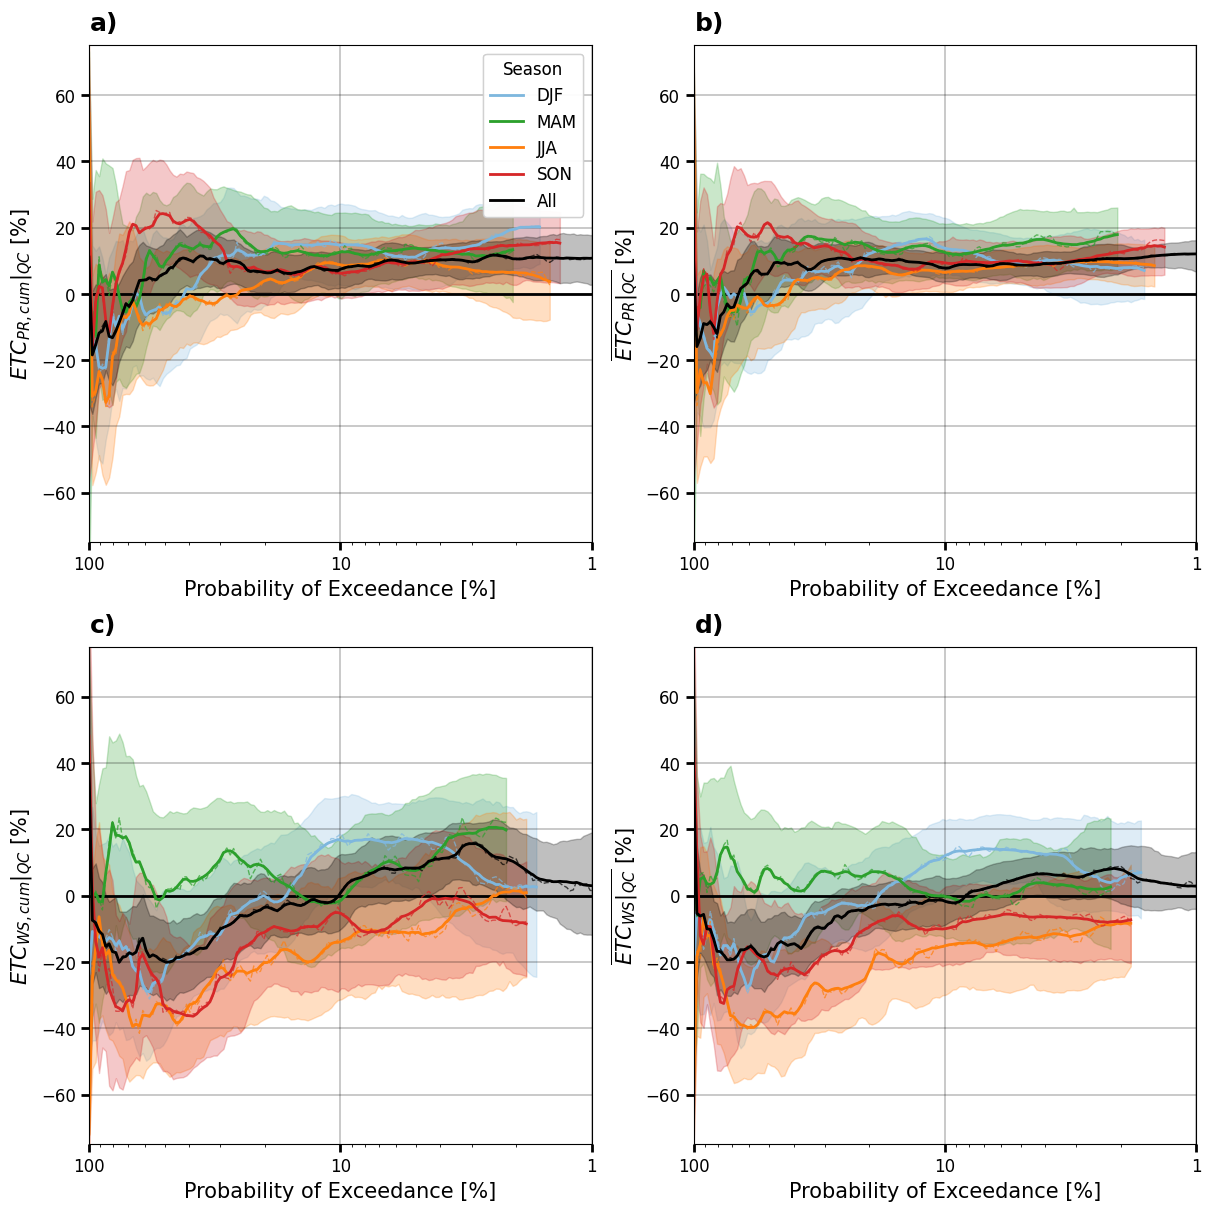

In [23]:
sim = 'UBF'
common_poe = np.logspace(np.log10(0.01), np.log10(100), 300)
min_events_threshold = 15

# --- paramètres bootstrap ---
nboot = 1000  # augmente si tu veux des CI plus lisses
ci_lower = 2.5
ci_upper = 97.5

fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for i, params in enumerate(plot_params):
    
    ax = axes[params["ax_index"]]
    ax.axhline(y=0, color='k', lw=2)
    
    for season, months in seasons.items():

        EETCs_hist = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if (
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            )
        ]
        EETCs_fut = [
            EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim_hist_fut[sim]]
            if (
                EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim_hist_fut[sim]][k]['min_pressure_date']).month in months
            )
        ]
        
        n_hist = len(EETCs_hist)
        n_fut  = len(EETCs_fut)
        
        # Trie les valeurs (descendant)
        EETCs_hist_sorted = np.sort(np.asarray(EETCs_hist))[::-1]
        EETCs_fut_sorted = np.sort(np.asarray(EETCs_fut))[::-1]

        # poe observés
        poe_hist = 100 * (np.arange(1, n_hist + 1) / n_hist)
        poe_fut  = 100 * (np.arange(1, n_fut + 1) / n_fut)

        # interp sur grille commune
        interp_hist = np.interp(common_poe, poe_hist, EETCs_hist_sorted, left=np.nan, right=np.nan)
        interp_fut  = np.interp(common_poe, poe_fut,  EETCs_fut_sorted,  left=np.nan, right=np.nan)

        # diff observée (ta formule, en % relatif)
        diff_obs = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)
        
        # --- Masque de validité (Règle des 15 cyclones) ---
        min_poe_hist = (min_events_threshold / n_hist) * 100
        min_poe_fut  = (min_events_threshold / n_fut) * 100
        cutoff_poe = max(min_poe_hist, min_poe_fut)
        mask_valid = common_poe >= cutoff_poe
        diff_obs[~mask_valid] = np.nan
        
        # ----------------------
        # BOOTSTRAP (pointwise)
        # ----------------------
        boot_changes = np.full((nboot, common_poe.size), np.nan)

        n_hist = len(EETCs_hist_sorted)
        n_fut  = len(EETCs_fut_sorted)

        for ib in range(nboot):
            # resample indices avec remise (cyclones entiers)
            idx_hist = np.random.randint(0, n_hist, size=n_hist)
            idx_fut  = np.random.randint(0, n_fut,  size=n_fut)

            h_b = np.sort(np.asarray(EETCs_hist_sorted)[idx_hist])[::-1]
            f_b = np.sort(np.asarray(EETCs_fut_sorted)[idx_fut])[::-1]

            poe_h_b = 100 * (np.arange(1, len(h_b) + 1) / len(h_b))
            poe_f_b = 100 * (np.arange(1, len(f_b) + 1) / len(f_b))

            interp_h_b = np.interp(common_poe, poe_h_b, h_b, left=np.nan, right=np.nan)
            interp_f_b = np.interp(common_poe, poe_f_b, f_b, left=np.nan, right=np.nan)

            # calcule diff bootstrap (même formule)
            diff_b = 100 * (interp_f_b - interp_h_b) / (interp_f_b + interp_h_b)

            boot_changes[ib, :] = diff_b

        # percentiles pointwise en tolérant NaN (zones trop rares resteront NaN)
        lower = np.nanpercentile(boot_changes, ci_lower, axis=0)
        median = np.nanpercentile(boot_changes, 50, axis=0)
        upper = np.nanpercentile(boot_changes, ci_upper, axis=0)
        
        # On applique le masque de validité (règle des 15 cyclones) aux résultats du bootstrap
        lower[~mask_valid] = np.nan
        median[~mask_valid] = np.nan
        upper[~mask_valid] = np.nan
        
        # plot: bande CI (masque les NaN) puis médiane et courbe observée
        valid = (~np.isnan(lower)) & (~np.isnan(upper))
        label = sim_label[sim]

        if np.any(valid):
            ax.fill_between(common_poe[valid], lower[valid], upper[valid], alpha=0.25, color=season_color[season])
            ax.plot(common_poe, median, linewidth=2, color=season_color[season])
        # plot de ta courbe observée (optionnel: en trait noir pointillé)
        ax.plot(common_poe, diff_obs, lw=1, color=season_color[season], linestyle='--', alpha=0.7)

    EETCs_hist = [
        EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim]
        if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]
    
    EETCs_fut = [
        EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim_hist_fut[sim]]
        if EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]
    
    n_hist = len(EETCs_hist)
    n_fut  = len(EETCs_fut)
    
    # Trie les valeurs (descendant)
    EETCs_hist_sorted = np.sort(np.asarray(EETCs_hist))[::-1]
    EETCs_fut_sorted = np.sort(np.asarray(EETCs_fut))[::-1]

    # poe observés
    poe_hist = 100 * (np.arange(1, n_hist + 1) / n_hist)
    poe_fut  = 100 * (np.arange(1, n_fut + 1) / n_fut)  

    # interp sur grille commune
    interp_hist = np.interp(common_poe, poe_hist, EETCs_hist_sorted, left=np.nan, right=np.nan)
    interp_fut  = np.interp(common_poe, poe_fut,  EETCs_fut_sorted,  left=np.nan, right=np.nan)

    # diff observée (ta formule, en % relatif)
    diff_obs = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)
    
    # --- Masque de validité (Règle des 15 cyclones) ---
    min_poe_hist = (min_events_threshold / n_hist) * 100
    min_poe_fut  = (min_events_threshold / n_fut) * 100
    cutoff_poe = max(min_poe_hist, min_poe_fut)
    mask_valid = common_poe >= cutoff_poe
    diff_obs[~mask_valid] = np.nan

    # ----------------------
    # BOOTSTRAP (pointwise)
    # ----------------------
    boot_changes = np.full((nboot, common_poe.size), np.nan)

    n_hist = len(EETCs_hist_sorted)
    n_fut  = len(EETCs_fut_sorted)

    for ib in range(nboot):
        # resample indices avec remise (cyclones entiers)
        idx_hist = np.random.randint(0, n_hist, size=n_hist)
        idx_fut  = np.random.randint(0, n_fut,  size=n_fut)

        h_b = np.sort(np.asarray(EETCs_hist_sorted)[idx_hist])[::-1]
        f_b = np.sort(np.asarray(EETCs_fut_sorted)[idx_fut])[::-1]

        poe_h_b = 100 * (np.arange(1, len(h_b) + 1) / len(h_b))
        poe_f_b = 100 * (np.arange(1, len(f_b) + 1) / len(f_b))

        interp_h_b = np.interp(common_poe, poe_h_b, h_b, left=np.nan, right=np.nan)
        interp_f_b = np.interp(common_poe, poe_f_b, f_b, left=np.nan, right=np.nan)

        # calcule diff bootstrap (même formule)
        diff_b = 100 * (interp_f_b - interp_h_b) / (interp_f_b + interp_h_b)

        boot_changes[ib, :] = diff_b

    # percentiles pointwise en tolérant NaN (zones trop rares resteront NaN)
    lower = np.nanpercentile(boot_changes, ci_lower, axis=0)
    median = np.nanpercentile(boot_changes, 50, axis=0)
    upper = np.nanpercentile(boot_changes, ci_upper, axis=0)
    
    # On applique le masque de validité (règle des 15 cyclones) aux résultats du bootstrap
    lower[~mask_valid] = np.nan
    median[~mask_valid] = np.nan
    upper[~mask_valid] = np.nan

    # plot: bande CI (masque les NaN) puis médiane et courbe observée
    valid = (~np.isnan(lower)) & (~np.isnan(upper))
    label = sim_label[sim]

    if np.any(valid):
        ax.fill_between(common_poe[valid], lower[valid], upper[valid], alpha=0.25, color='k')
        ax.plot(common_poe, median, linewidth=2, color='k')
    # plot de ta courbe observée (optionnel: en trait noir pointillé)
    ax.plot(common_poe, diff_obs, lw=1, color='k', linestyle='--', alpha=0.7)
    
    letter = f"$\\mathbf{{{chr(97+i)})}}$"
    ax.text(0, 1.02, letter, transform=ax.transAxes, fontsize=18, ha='left', va='bottom')
    ax.set_xlabel("Probability of Exceedance [%]", fontsize=15)
    ax.set_xlim(100, 1)
    ax.set_xscale('log')
    ax.set_ylabel(params["label"] + ' [%]', fontsize=15)
    ax.set_ylim(-75, 75)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    if params["ax_index"] == (0, 0):
        season_handles = [
            Line2D([0], [0], color=season_color[season], linestyle='-', linewidth=2, label=season)
            for season in seasons]
    
        season_handles.append(
        Line2D([0], [0], color='k', linestyle='-', linewidth=2, label='All'))
        
        legend1 = ax.legend(handles=season_handles, title='Season', loc='best', fontsize=12, title_fontsize=12)
    
        ax.add_artist(legend1)
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')